In [1]:
import sys 
sys.path.append("/home/feity/cryoem/")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import torch
import importlib 
import modules
import data
import postprocess 

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load model
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1_mm/", "stage3/epoch=1-total_validate_loss=0.7363.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([1]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([1, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1
model with output classes 2
model receiving class weights tensor([1.0000, 0.1000])
using consistency regularization coef 0.5


/home/feity/cryoem/utils.py:1058: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters ['model.class_labels_classifier.weight', 'model.class_labels_classifier.bias', 'additional_input_layer.layer1.weight', 'additional_input_layer.layer1.bias', 'additional_input_layer.layer2.weight', 'additional_input_layer.layer2.bias', 'gnn.conv1.lin_l.weight', 'gnn.conv1.lin_l.bias', 'gnn.conv1.lin_r.weight', 'gnn.conv2.lin_l.weight', 'gnn.conv2.lin_l.bias', 'gnn.conv2.lin_r.weight', 'gnn.conv3.lin_l.weight', 'gnn.conv3.lin_l.bias', 'gnn.conv3.lin_r.weight', 'gnn.cls_head.0.weight', 'gnn.cls_head.0.bias', 'gnn.cls_head.2.weight', 'gnn.cls_head.2.bias', 'gnn.box_head.0.weight', 'gnn.box_head.0.bias', 'gnn.box_head.2.weight', 'gnn.box_head.2.bias', 'gnn.edge_head.0.weight', 'gnn.edge_head.0.bias', 'gnn.edge_head.2.weight', 'gnn.edge_head.2.bias', 'gnn.edge_head.4.weight', 'cri.weight']
finish loading parameters


/home/feity/cryoem/utils.py:1096: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [7]:
# build test dataset and generate dataframe
# Note: make sure the gap is consistent with the model training
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate_mitomemb.pkl",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getConstantTransform(),
    add_classname=True,
    filtermin=0
)
df = postprocess.generatedf(model, dataset, gap = 5, columns=["mitochondria_memb", "None"])

reading dataset: /data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate_mitomemb.pkl
dataset map classes:  {'mitochondria_memb': 0}
dataset length: 52


In [50]:
import postprocess
importlib.reload(postprocess)

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1
df["largest"].value_counts()
# params= {
#     "endoplasmic_reticulum_or_Golgi":{"min_prob":0.5, "nms":0.6, "dbscan_prams":{"min_samples": 25, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 15}}, 
#     "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 100}}, 
#     "nucleus":{"min_prob":0.2, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 100}}, 
#     "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 10, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 15}}, 
# }

params= {
    "mitochondria_memb":{"min_prob":0.85, "nms":0.2, "dbscan_prams":{"min_samples": 25, "eps": 0.4, "dis_penalty_coef": 10.0*(1/500), "dis_penalty_cutoff": 30}}, 
}

mark_and_filter = {
    "mitochondria_memb":{"max_cnt":10, "remove_iou": 0.6, "min_samples":20}, 
}

# call object detection, 
# object from larger to smaller is recommended
# for i in ["nucleus", "mitochondria", "endoplasmic_reticulum_or_Golgi", "ribo"]:
for i in ["mitochondria_memb"]:  
    subdf = postprocess.processClass(df, i, **params[i])
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])



25 0.4 0.02 30
number of instances in class  4


In [51]:
subdf["label"].value_counts()

label
-1    422
 0    134
 2     55
 1     44
Name: count, dtype: int64

In [9]:
df["label"].value_counts()

label
                     804
mitochondria_memb    378
Name: count, dtype: int64

/tmp/ipykernel_2899916/2458179465.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/utils.py:225: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


[0]


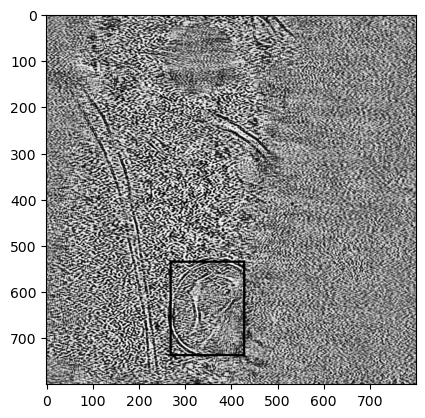

In [172]:
# take one slice and visualize
take = 180
q = df["z"]

subdf = df
subdf = subdf[(subdf["label"] != "")]
subdf = subdf[subdf["z"] == take]

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

# subdf2 = subdf.loc[need]
subdf2 = subdf

# subdf2 = df.loc[need2]

""" if use dbscan results """
subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
print(subdf2["label_id"].unique())
labels = {"bboxes": bboxes, "labels": ["need"] * len(bboxes)} 
utils.drawannotation(img, labels, font_size=100)

In [152]:
subdf = df[df["label"] == "mitochondria_memb"]
subdf = subdf[subdf["label_id"] == 0]
inputs, stage1_output = postprocess.getMaskInputs(subdf, model, dataset, **prepare_mask_input[label])

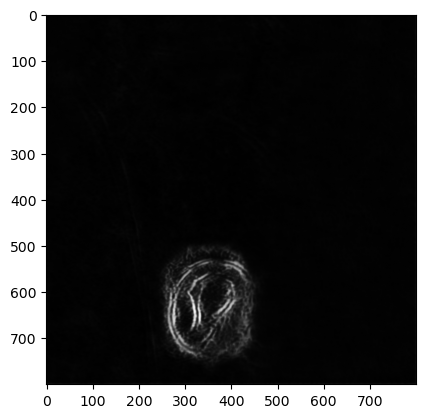

In [171]:
# generate masks from model and view the raw outputs
smoothed_masks = postprocess.getMasks(model, inputs, 2.0, on_z_only=True)
plt.imshow(smoothed_masks[20], cmap="gray")

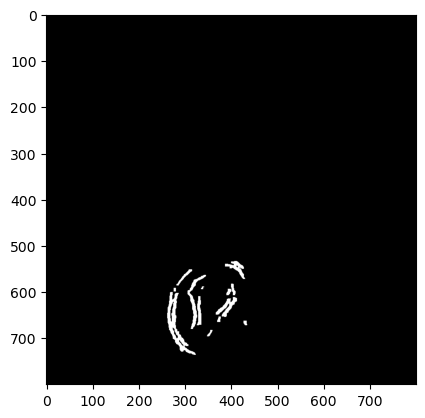

In [173]:
# test refining parameters
importlib.reload(postprocess)
mask = postprocess.refineMembMask(smoothed_masks[20], sigma=0.0, threshold=0.25, kernal_size=3, morph_open_iterations=2, morph_close_iterations=1)
plt.imshow(mask, cmap="gray")
# smoothed_masks

In [11]:
model = model.cuda(0)

In [104]:
importlib.reload(postprocess)
mask_thres = {
    "mitochondria_memb":0.3,
    
}
prepare_mask_input = {
    "mitochondria_memb":{"class_id":0, "min_length": 40, "extend": 5}, 
}
refine_mask = {
    "mitochondria_memb":{"smooth": 2.0, "kernal_size":3, "morph_open_iterations": 2, "morph_close_iterations": 1}, 
}
stage1_output = {}
build_masks = {
    "mitochondria_memb": np.zeros((500, 800, 800), dtype=int) 
}
all_inputs = {}
for (label, label_id), r in df.groupby(["label", "label_id"]):
    if label == "":
        continue
    if label_id == -1:
        continue
    print(label, label_id, len(r))
    # if label == "ribo":
    #     continue
    if "%s_%s"%(label, label_id) in all_inputs:
        continue
    inputs, stage1_output = postprocess.getMaskInputs(r, model, dataset, **prepare_mask_input[label], stage1_outputs=stage1_output)
    # inputs = postprocess.getMaskInputsStage2(
    #     r,
    #     dataset, 
    #     **prepare_mask_input[label],
    #     res = res
    # )
    all_inputs["%s_%s"%(label, label_id)] = inputs
    smoothed_masks = postprocess.getMasks(model, inputs, refine_mask[label]["smooth"], on_z_only=True)

    minz = np.min(list(inputs.keys()))
    maxz = np.max(list(inputs.keys()))
    t = np.max(smoothed_masks)
    # masks = [] 
    for i in range(len(smoothed_masks)):
        mask = smoothed_masks[i]
        # box = inputs[i + minz]["input_mask"]
        # t1 = (mask * box).sum() / box.sum()
        # t2 = (mask * (1 - box)).sum() / (1 - box).sum()
        thres = t*mask_thres[label]
        refined_mask = postprocess.refineMembMask(
            mask,
            threshold = thres,
            **refine_mask[label],
        )
        smoothed_masks[i] = refined_mask
    smoothed_masks = smoothed_masks.astype(np.int32)
    
    for i in range(minz, maxz+1):
        build_masks[label][i][smoothed_masks[i-minz]>1] = (label_id+1)
        # masks.append(refined_mask)
    
    

mitochondria_memb 0 134
mitochondria_memb 1 44
mitochondria_memb 2 55


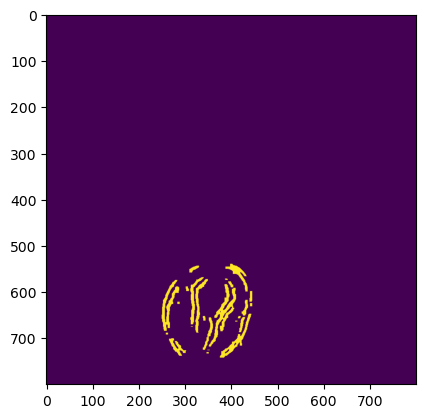

In [151]:
plt.imshow(build_masks["mitochondria_memb"][220])